
Processing system: PE-A1

Filtering file:
  /blue/jsampath/avemula/Paper1_PE/Classical/PE_A1/Replica1/linear.lammpstrj
Output filtered file:
  /blue/jsampath/avemula/Paper1_PE/Classical/PE_A1/Replica1/Only_target_type.lammpstrj
Done filtering: /blue/jsampath/avemula/Paper1_PE/Classical/PE_A1/Replica1/Only_target_type.lammpstrj
Read filtered file: /blue/jsampath/avemula/Paper1_PE/Classical/PE_A1/Replica1/Only_target_type.lammpstrj
DataFrame shape: (240240, 13)
num_particles = 240
first few times = [0. 1. 2. 3. 4. 5. 6. 7. 8. 9.] ...
Frame spacing (ps) = 1.0

Replica file: /blue/jsampath/avemula/Paper1_PE/Classical/PE_A1/Replica1/linear.lammpstrj
lag_ps     = 1.0
count      = 240000
min/max    = 0.0109, 4.5996
mean       = 0.7380
std        = 0.3397

Replica file: /blue/jsampath/avemula/Paper1_PE/Classical/PE_A1/Replica1/linear.lammpstrj
lag_ps     = 10.0
count      = 237840
min/max    = 0.0140, 6.8731
mean       = 1.3466
std        = 0.6787

Replica file: /blue/jsampath/avemula/Paper1_

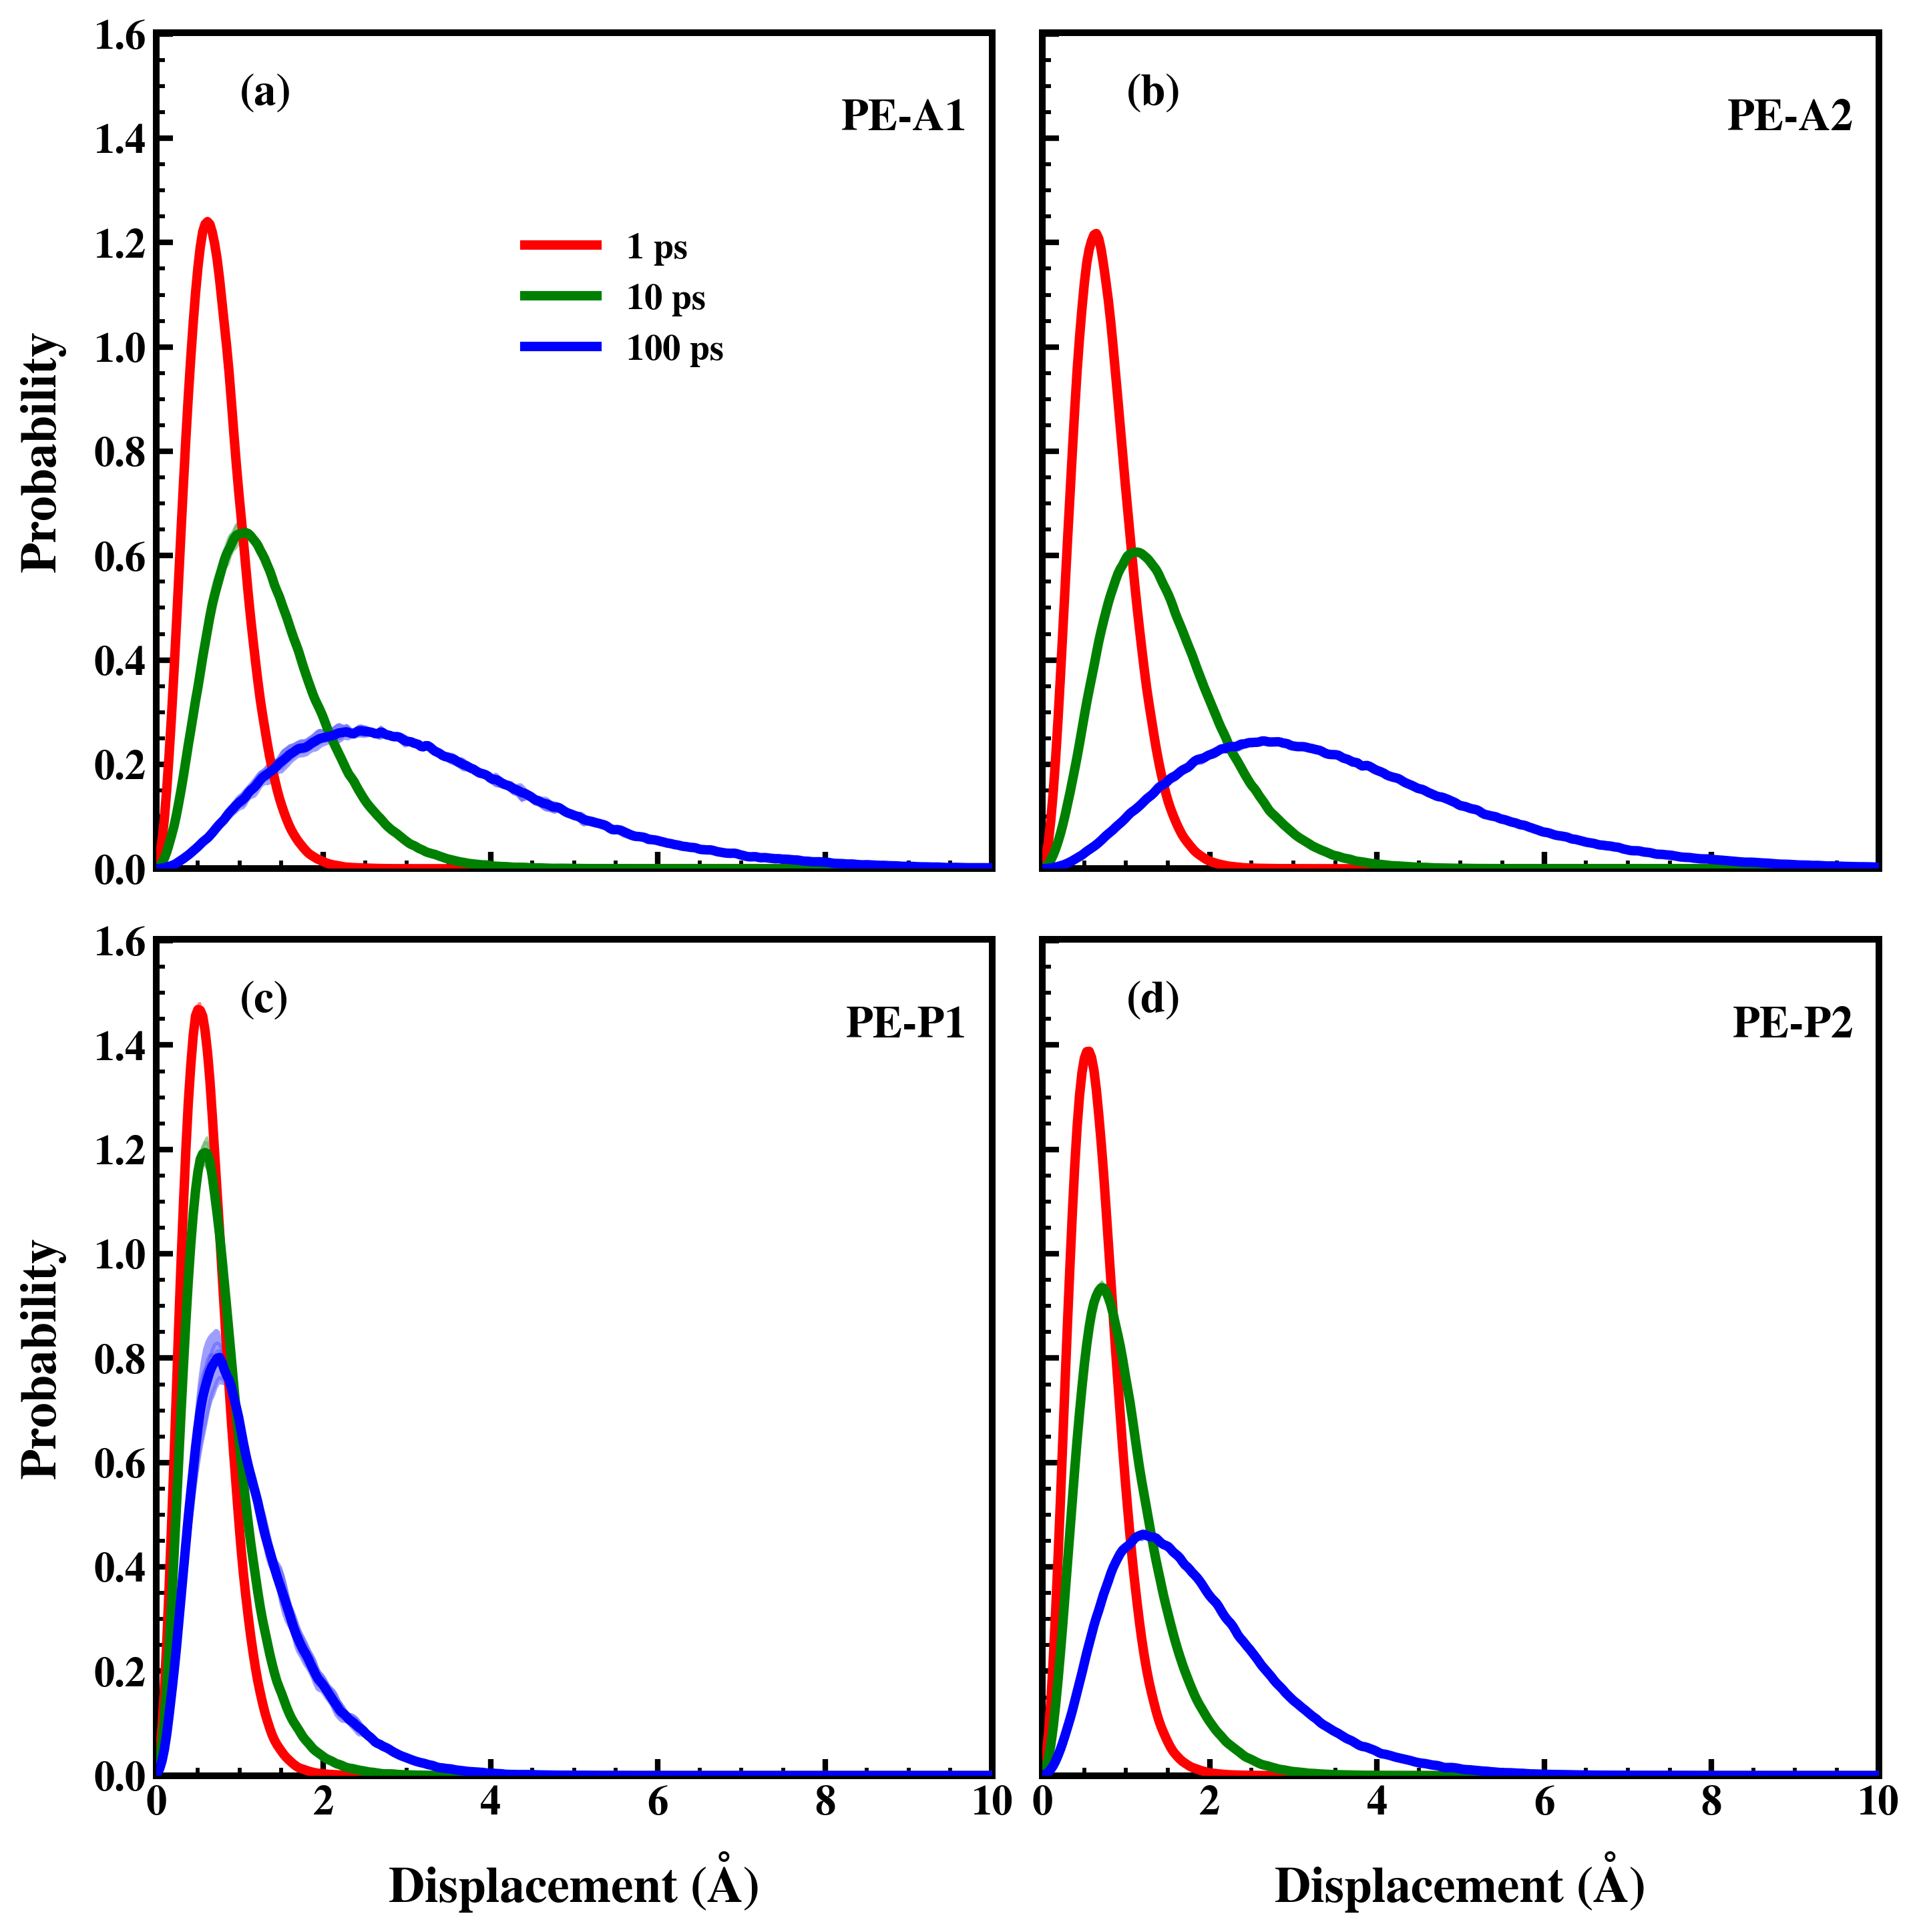


Saved:
van_hove_2x2_replicas_shadowbands.png
van_hove_2x2_replicas_shadowbands.pdf


In [ ]:
#!/usr/bin/env python3




import os
import fileinput
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
from scipy.ndimage import gaussian_filter1d

# =========================================================
# SETTINGS
# =========================================================
BASE = "/blue/jsampath/avemula/Paper1_PE/Classical"

SYSTEMS = {
    "PE-A1": {
        "atom_type": 10,
        "files": [
            f"{BASE}/PE_A1/Replica1/linear.lammpstrj",
            f"{BASE}/PE_A1/Replica2/linear.lammpstrj",
            f"{BASE}/PE_A1/Replica3/linear.lammpstrj",
        ],
    },
    "PE-A2": {
        "atom_type": 9,
        "files": [
            f"{BASE}/PE_A2/Replica1/linear.lammpstrj",
            f"{BASE}/PE_A2/Replica2/linear.lammpstrj",
            f"{BASE}/PE_A2/Replica3/linear.lammpstrj",
        ],
    },
    "PE-P1": {
        "atom_type": 10,
        "files": [
            f"{BASE}/PE_P1/Replica1/linear.lammpstrj",
            f"{BASE}/PE_P1/Replica2/linear.lammpstrj",
            f"{BASE}/PE_P1/Replica3/linear.lammpstrj",
        ],
    },
    "PE-P2": {
        "atom_type": 9,
        "files": [
            f"{BASE}/PE_P2/Replica1/linear.lammpstrj",
            f"{BASE}/PE_P2/Replica2/linear.lammpstrj",
            f"{BASE}/PE_P2/Replica3/linear.lammpstrj",
        ],
    },
}

TIME_CUTOFF = 1000000
TIME_DIVIDE = 1000.0
LAGS_PS = [1.0, 10.0, 100.0]

FILTERED_SUFFIX = "Only_target_type.lammpstrj"

OUT_PNG = "van_hove_2x2_replicas_shadowbands.png"
OUT_PDF = "van_hove_2x2_replicas_shadowbands.pdf"

# =========================================================
# PLOT SETTINGS
# =========================================================
XMIN = 0.0
XMAX = 10.0
NBINS = 350
BINS = np.linspace(XMIN, XMAX, NBINS)
SMOOTH_SIGMA = 1.0
DPI = 300

LINEWIDTH_MEAN = 3.4
LINEWIDTH_REPLICA = 1.2
REPLICA_ALPHA = 0.22
BAND_ALPHA = 0.38

AXIS_WIDTH = 2.4
MAJOR_TICK_WIDTH = 2.0
MINOR_TICK_WIDTH = 1.4
MAJOR_TICK_LEN = 6
MINOR_TICK_LEN = 3

LABEL_SIZE = 18
TICK_SIZE = 15
TEXT_SIZE = 16
LEGEND_SIZE = 13

# increase band only for visibility
BAND_SCALE = 1.5

colors = {
    1.0: "red",
    10.0: "green",
    100.0: "blue",
}

labels = {
    1.0: "1 ps",
    10.0: "10 ps",
    100.0: "100 ps",
}

# ACS-like style
mpl.rcParams["font.family"] = "Sans-Derif"
mpl.rcParams["mathtext.fontset"] = "stix"
mpl.rcParams["axes.linewidth"] = AXIS_WIDTH
mpl.rcParams["xtick.major.width"] = MAJOR_TICK_WIDTH
mpl.rcParams["ytick.major.width"] = MAJOR_TICK_WIDTH
mpl.rcParams["xtick.minor.width"] = MINOR_TICK_WIDTH
mpl.rcParams["ytick.minor.width"] = MINOR_TICK_WIDTH
mpl.rcParams["xtick.major.size"] = MAJOR_TICK_LEN
mpl.rcParams["ytick.major.size"] = MAJOR_TICK_LEN
mpl.rcParams["xtick.minor.size"] = MINOR_TICK_LEN
mpl.rcParams["ytick.minor.size"] = MINOR_TICK_LEN


# =========================================================
# FILTER ONE TRAJECTORY
# =========================================================
def filter_trajectory(input_traj, atom_type_to_keep):
    outdir = os.path.dirname(input_traj)
    filtered_traj = os.path.join(outdir, FILTERED_SUFFIX)

    print(f"\nFiltering file:\n  {input_traj}")
    print(f"Output filtered file:\n  {filtered_traj}")

    with open(filtered_traj, "w") as OUT:
        IN = fileinput.input([input_traj])

        while True:
            headers = [IN.readline() for _ in range(9)]
            if any(h == "" for h in headers):
                break

            try:
                natoms = int(headers[3].strip())
            except ValueError:
                raise RuntimeError(f"Could not parse NUMBER OF ATOMS in file: {input_traj}")

            kept_atoms = []
            for _ in range(natoms):
                line = IN.readline()
                if line == "":
                    raise RuntimeError(f"Unexpected EOF inside atom block in file: {input_traj}")

                parts = line.split()
                if len(parts) < 3:
                    raise RuntimeError(f"Malformed atom line in {input_traj}:\n{line}")

                typ = int(parts[2])
                if typ == atom_type_to_keep:
                    kept_atoms.append(line)

            OUT.writelines(headers[:3])
            OUT.write(f"{len(kept_atoms)}\n")
            OUT.writelines(headers[4:])
            for atom_line in kept_atoms:
                OUT.write(atom_line)

    print(f"Done filtering: {filtered_traj}")
    return filtered_traj


# =========================================================
# READ FILTERED FILE
# =========================================================
def read_filtered_traj(filtered_traj, time_cutoff, time_divide):
    """
    Reads filtered trajectory with columns:
    ITEM: ATOMS id mol type x y z xu yu zu
    """
    col_names = ["id", "mol", "type", "x", "y", "z", "xu", "yu", "zu"]

    with open(filtered_traj, "r") as f:
        lines = f.readlines()

    if len(lines) < 9:
        raise RuntimeError(f"Filtered trajectory is too short or empty: {filtered_traj}")

    data = []
    num_particles = None

    for i in range(len(lines)):
        if "ITEM: TIMESTEP" in lines[i]:
            timestep = int(lines[i + 1])

            if timestep > time_cutoff:
                break

            num_particles = int(lines[i + 3].strip())

            for j in range(i + 9, i + 9 + num_particles):
                parts = lines[j].split()
                if len(parts) < 9:
                    continue

                particle_id, mol, particle_type, x, y, z, xu, yu, zu = parts[:9]
                data.append([
                    timestep,
                    particle_id,
                    mol,
                    particle_type,
                    x, y, z, xu, yu, zu
                ])

    df = pd.DataFrame(data, columns=["time"] + col_names)

    if df.empty:
        raise RuntimeError(f"No data found in filtered file: {filtered_traj}")

    df[["id", "mol", "type"]] = df[["id", "mol", "type"]].astype(int)
    df[["x", "y", "z", "xu", "yu", "zu"]] = df[["x", "y", "z", "xu", "yu", "zu"]].astype(float)
    df["time"] = df["time"].astype(int) / time_divide

    # use xu yu zu directly
    df["xa"] = df["xu"]
    df["ya"] = df["yu"]
    df["za"] = df["zu"]

    df = df.sort_values(["time", "id"]).reset_index(drop=True)
    times = np.sort(df["time"].unique())

    if len(times) < 2:
        raise RuntimeError(f"Not enough frames in {filtered_traj}")

    dt_ps = times[1] - times[0]

    print(f"Read filtered file: {filtered_traj}")
    print("DataFrame shape:", df.shape)
    print("num_particles =", num_particles)
    print("first few times =", times[:10], "...")
    print("Frame spacing (ps) =", dt_ps)

    return df, times, dt_ps, num_particles


# =========================================================
# COLLECT DRIFT-CORRECTED DISPLACEMENTS
# =========================================================
def collect_displacements_for_lag(df, times, lag_ps, time_tol=1e-8):
    out = []
    time_set = set(np.round(times, 8))

    for t0 in times:
        t1 = t0 + lag_ps

        if np.round(t1, 8) not in time_set:
            continue

        f0 = df[np.isclose(df["time"], t0, atol=time_tol)].sort_values("id").reset_index(drop=True)
        f1 = df[np.isclose(df["time"], t1, atol=time_tol)].sort_values("id").reset_index(drop=True)

        ids0 = f0["id"].to_numpy()
        ids1 = f1["id"].to_numpy()

        common_ids, idx0, idx1 = np.intersect1d(
            ids0, ids1,
            assume_unique=False,
            return_indices=True
        )

        if len(common_ids) == 0:
            continue

        r0 = f0.loc[idx0, ["xa", "ya", "za"]].to_numpy()
        r1 = f1.loc[idx1, ["xa", "ya", "za"]].to_numpy()

        dr_vec = r1 - r0

        # drift correction
        drift = dr_vec.mean(axis=0)
        dr_vec = dr_vec - drift

        dr = np.linalg.norm(dr_vec, axis=1)
        dr = dr[np.isfinite(dr)]

        if dr.size > 0:
            out.append(dr)

    if len(out) == 0:
        raise RuntimeError(f"No displacements found for lag {lag_ps} ps")

    return np.concatenate(out)


# =========================================================
# CONVERT ONE REPLICA DISPLACEMENT ARRAY TO SMOOTH HISTOGRAM
# =========================================================
def displacement_to_hist(dr, bins):
    dr_plot = dr[(dr >= bins[0]) & (dr <= bins[-1])]

    if dr_plot.size == 0:
        return None, None

    hist, _ = np.histogram(dr_plot, bins=bins, density=True)
    hist_smooth = gaussian_filter1d(hist, sigma=SMOOTH_SIGMA)
    centers = 0.5 * (bins[:-1] + bins[1:])

    return centers, hist_smooth


# =========================================================
# PROCESS ONE SYSTEM
# =========================================================
def process_system(system_name, system_info):
    atom_type_to_keep = system_info["atom_type"]
    traj_files = system_info["files"]

    replica_results = []

    print("\n" + "=" * 80)
    print(f"Processing system: {system_name}")
    print("=" * 80)

    for traj_file in traj_files:
        if not os.path.exists(traj_file):
            print(f"WARNING: file not found, skipping:\n  {traj_file}")
            continue

        try:
            filtered_traj = filter_trajectory(traj_file, atom_type_to_keep)

            df, times, dt_ps, num_particles = read_filtered_traj(
                filtered_traj,
                time_cutoff=TIME_CUTOFF,
                time_divide=TIME_DIVIDE
            )

            replica_dict = {}

            for lag_ps in LAGS_PS:
                ratio = lag_ps / dt_ps
                if not np.isclose(ratio, round(ratio), atol=1e-8):
                    raise RuntimeError(
                        f"Requested lag {lag_ps} ps is not an integer multiple of "
                        f"frame spacing {dt_ps} ps for file {traj_file}"
                    )

                dr = collect_displacements_for_lag(df, times, lag_ps)
                replica_dict[lag_ps] = dr

                print(f"\nReplica file: {traj_file}")
                print(f"lag_ps     = {lag_ps}")
                print(f"count      = {len(dr)}")
                print(f"min/max    = {dr.min():.4f}, {dr.max():.4f}")
                print(f"mean       = {dr.mean():.4f}")
                print(f"std        = {dr.std():.4f}")

            replica_results.append(replica_dict)

        except Exception as e:
            print(f"WARNING: skipping replica due to error:\n  {traj_file}\n  {e}")
            continue

    if len(replica_results) == 0:
        raise RuntimeError(f"No valid replicas found for system {system_name}")

    return replica_results


# =========================================================
# HISTOGRAM MEAN/STD FOR ONE SYSTEM AND ONE LAG
# =========================================================
def histogram_mean_std(replica_results_for_one_system, lag_ps, bins):
    hists = []
    centers_out = None

    for replica_dict in replica_results_for_one_system:
        if lag_ps not in replica_dict:
            continue

        dr = replica_dict[lag_ps]
        centers, hist_smooth = displacement_to_hist(dr, bins)

        if centers is None:
            continue

        centers_out = centers
        hists.append(hist_smooth)

    if len(hists) == 0:
        raise RuntimeError(f"No histogram data found for lag {lag_ps}")

    hists = np.array(hists)
    mean_hist = np.mean(hists, axis=0)

    if hists.shape[0] > 1:
        std_hist = np.std(hists, axis=0, ddof=1)
    else:
        std_hist = np.zeros_like(mean_hist)

    return centers_out, mean_hist, std_hist, hists


# =========================================================
# RUN ALL SYSTEMS
# =========================================================
all_results = {}

for sys_name, sys_info in SYSTEMS.items():
    all_results[sys_name] = process_system(sys_name, sys_info)


# =========================================================
# GLOBAL Y-LIMIT
# =========================================================
all_ymax_candidates = []

for sys_name in ["PE-A1", "PE-A2", "PE-P1", "PE-P2"]:
    replica_results = all_results[sys_name]

    for lag in LAGS_PS:
        centers, mean_hist, std_hist, hists = histogram_mean_std(
            replica_results_for_one_system=replica_results,
            lag_ps=lag,
            bins=BINS
        )

        upper = mean_hist + BAND_SCALE * std_hist
        all_ymax_candidates.append(np.max(upper))

YMIN = 0.0
YMAX = 1.08 * max(all_ymax_candidates)


# =========================================================
# CREATE 2x2 PANEL LAYOUT
# =========================================================
fig, axes = plt.subplots(
    2, 2,
    figsize=(10, 10),
    dpi=DPI,
    sharex=True,
    sharey=True
)

axes = axes.flatten()
system_order = ["PE-A1", "PE-A2", "PE-P1", "PE-P2"]
panel_tags = ["(a)", "(b)", "(c)", "(d)"]

for i, (ax, sys_name) in enumerate(zip(axes, system_order)):
    replica_results = all_results[sys_name]

    for lag in LAGS_PS:
        centers, mean_hist, std_hist, hists = histogram_mean_std(
            replica_results_for_one_system=replica_results,
            lag_ps=lag,
            bins=BINS
        )

        # faint individual replica curves to show replica usage
        for hist_rep in hists:
            ax.plot(
                centers,
                hist_rep,
                lw=LINEWIDTH_REPLICA,
                color=colors[lag],
                alpha=REPLICA_ALPHA,
                zorder=1
            )

        # visible shadow band
        lower = np.clip(mean_hist - BAND_SCALE * std_hist, 0, None)
        upper = mean_hist + BAND_SCALE * std_hist

        ax.fill_between(
            centers,
            lower,
            upper,
            color=colors[lag],
            alpha=BAND_ALPHA,
            linewidth=0,
            zorder=2
        )

        # thick mean curve
        ax.plot(
            centers,
            mean_hist,
            lw=LINEWIDTH_MEAN,
            color=colors[lag],
            label=labels[lag],
            zorder=3
        )

    ax.set_xlim(XMIN, XMAX)
    ax.set_ylim(YMIN, YMAX)

    ax.text(
        0.10, 0.95, panel_tags[i],
        transform=ax.transAxes,
        ha="left",
        va="top",
        fontsize=TEXT_SIZE,
        fontweight="bold"
    )

    ax.text(
        0.97, 0.92, sys_name,
        transform=ax.transAxes,
        ha="right",
        va="top",
        fontsize=TEXT_SIZE,
        fontweight="bold"
    )

    ax.tick_params(
        axis="both",
        which="major",
        direction="in",
        labelsize=TICK_SIZE,
        width=MAJOR_TICK_WIDTH,
        length=MAJOR_TICK_LEN,
        top=False,
        right=False
    )

    ax.tick_params(
        axis="both",
        which="minor",
        direction="in",
        width=MINOR_TICK_WIDTH,
        length=MINOR_TICK_LEN,
        top=False,
        right=False
    )

    ax.minorticks_on()

    for tick in ax.get_xticklabels():
        tick.set_fontweight("bold")
    for tick in ax.get_yticklabels():
        tick.set_fontweight("bold")

    for spine in ax.spines.values():
        spine.set_linewidth(AXIS_WIDTH)

    ax.set_box_aspect(1)

# Left column y-labels only
axes[0].set_ylabel("Probability", fontsize=LABEL_SIZE, fontweight="bold", labelpad=10)
axes[2].set_ylabel("Probability", fontsize=LABEL_SIZE, fontweight="bold", labelpad=10)

# Bottom row x-labels only
axes[2].set_xlabel("Displacement (Å)", fontsize=LABEL_SIZE, fontweight="bold", labelpad=10)
axes[3].set_xlabel("Displacement (Å)", fontsize=LABEL_SIZE, fontweight="bold", labelpad=10)

# Hide top-row x tick labels
axes[0].tick_params(labelbottom=False)
axes[1].tick_params(labelbottom=False)

# Hide right-column y tick labels
axes[1].tick_params(labelleft=False)
axes[3].tick_params(labelleft=False)

# Legend only in first panel
axes[0].legend(
    loc="upper center",
    bbox_to_anchor=(0.56, 0.80),
    ncol=1,
    frameon=False,
    prop={"weight": "bold", "size": LEGEND_SIZE}
)

# Spacing
plt.subplots_adjust(
    hspace=0.06,
    wspace=0.06,
    left=0.12,
    right=0.98,
    bottom=0.10,
    top=0.98
)

plt.savefig(OUT_PNG, dpi=DPI, bbox_inches="tight")
plt.savefig(OUT_PDF, dpi=DPI, bbox_inches="tight")
plt.show()

print("\nSaved:")
print(OUT_PNG)
print(OUT_PDF)


Processing system: PE-A1

Filtering file:
  /blue/jsampath/avemula/Paper1_PE/Classical/PE_A1/Replica1/linear.lammpstrj
Output filtered file:
  /blue/jsampath/avemula/Paper1_PE/Classical/PE_A1/Replica1/Only_target_type.lammpstrj
Done filtering: /blue/jsampath/avemula/Paper1_PE/Classical/PE_A1/Replica1/Only_target_type.lammpstrj
Read filtered file: /blue/jsampath/avemula/Paper1_PE/Classical/PE_A1/Replica1/Only_target_type.lammpstrj
DataFrame shape: (240240, 13)
num_particles = 240
first few times = [0. 1. 2. 3. 4. 5. 6. 7. 8. 9.] ...
Frame spacing (ps) = 1.0

Replica file: /blue/jsampath/avemula/Paper1_PE/Classical/PE_A1/Replica1/linear.lammpstrj
lag_ps     = 1.0
count      = 240000
min/max    = 0.0109, 4.5996
mean       = 0.7380
std        = 0.3397

Replica file: /blue/jsampath/avemula/Paper1_PE/Classical/PE_A1/Replica1/linear.lammpstrj
lag_ps     = 10.0
count      = 237840
min/max    = 0.0140, 6.8731
mean       = 1.3466
std        = 0.6787

Replica file: /blue/jsampath/avemula/Paper1_

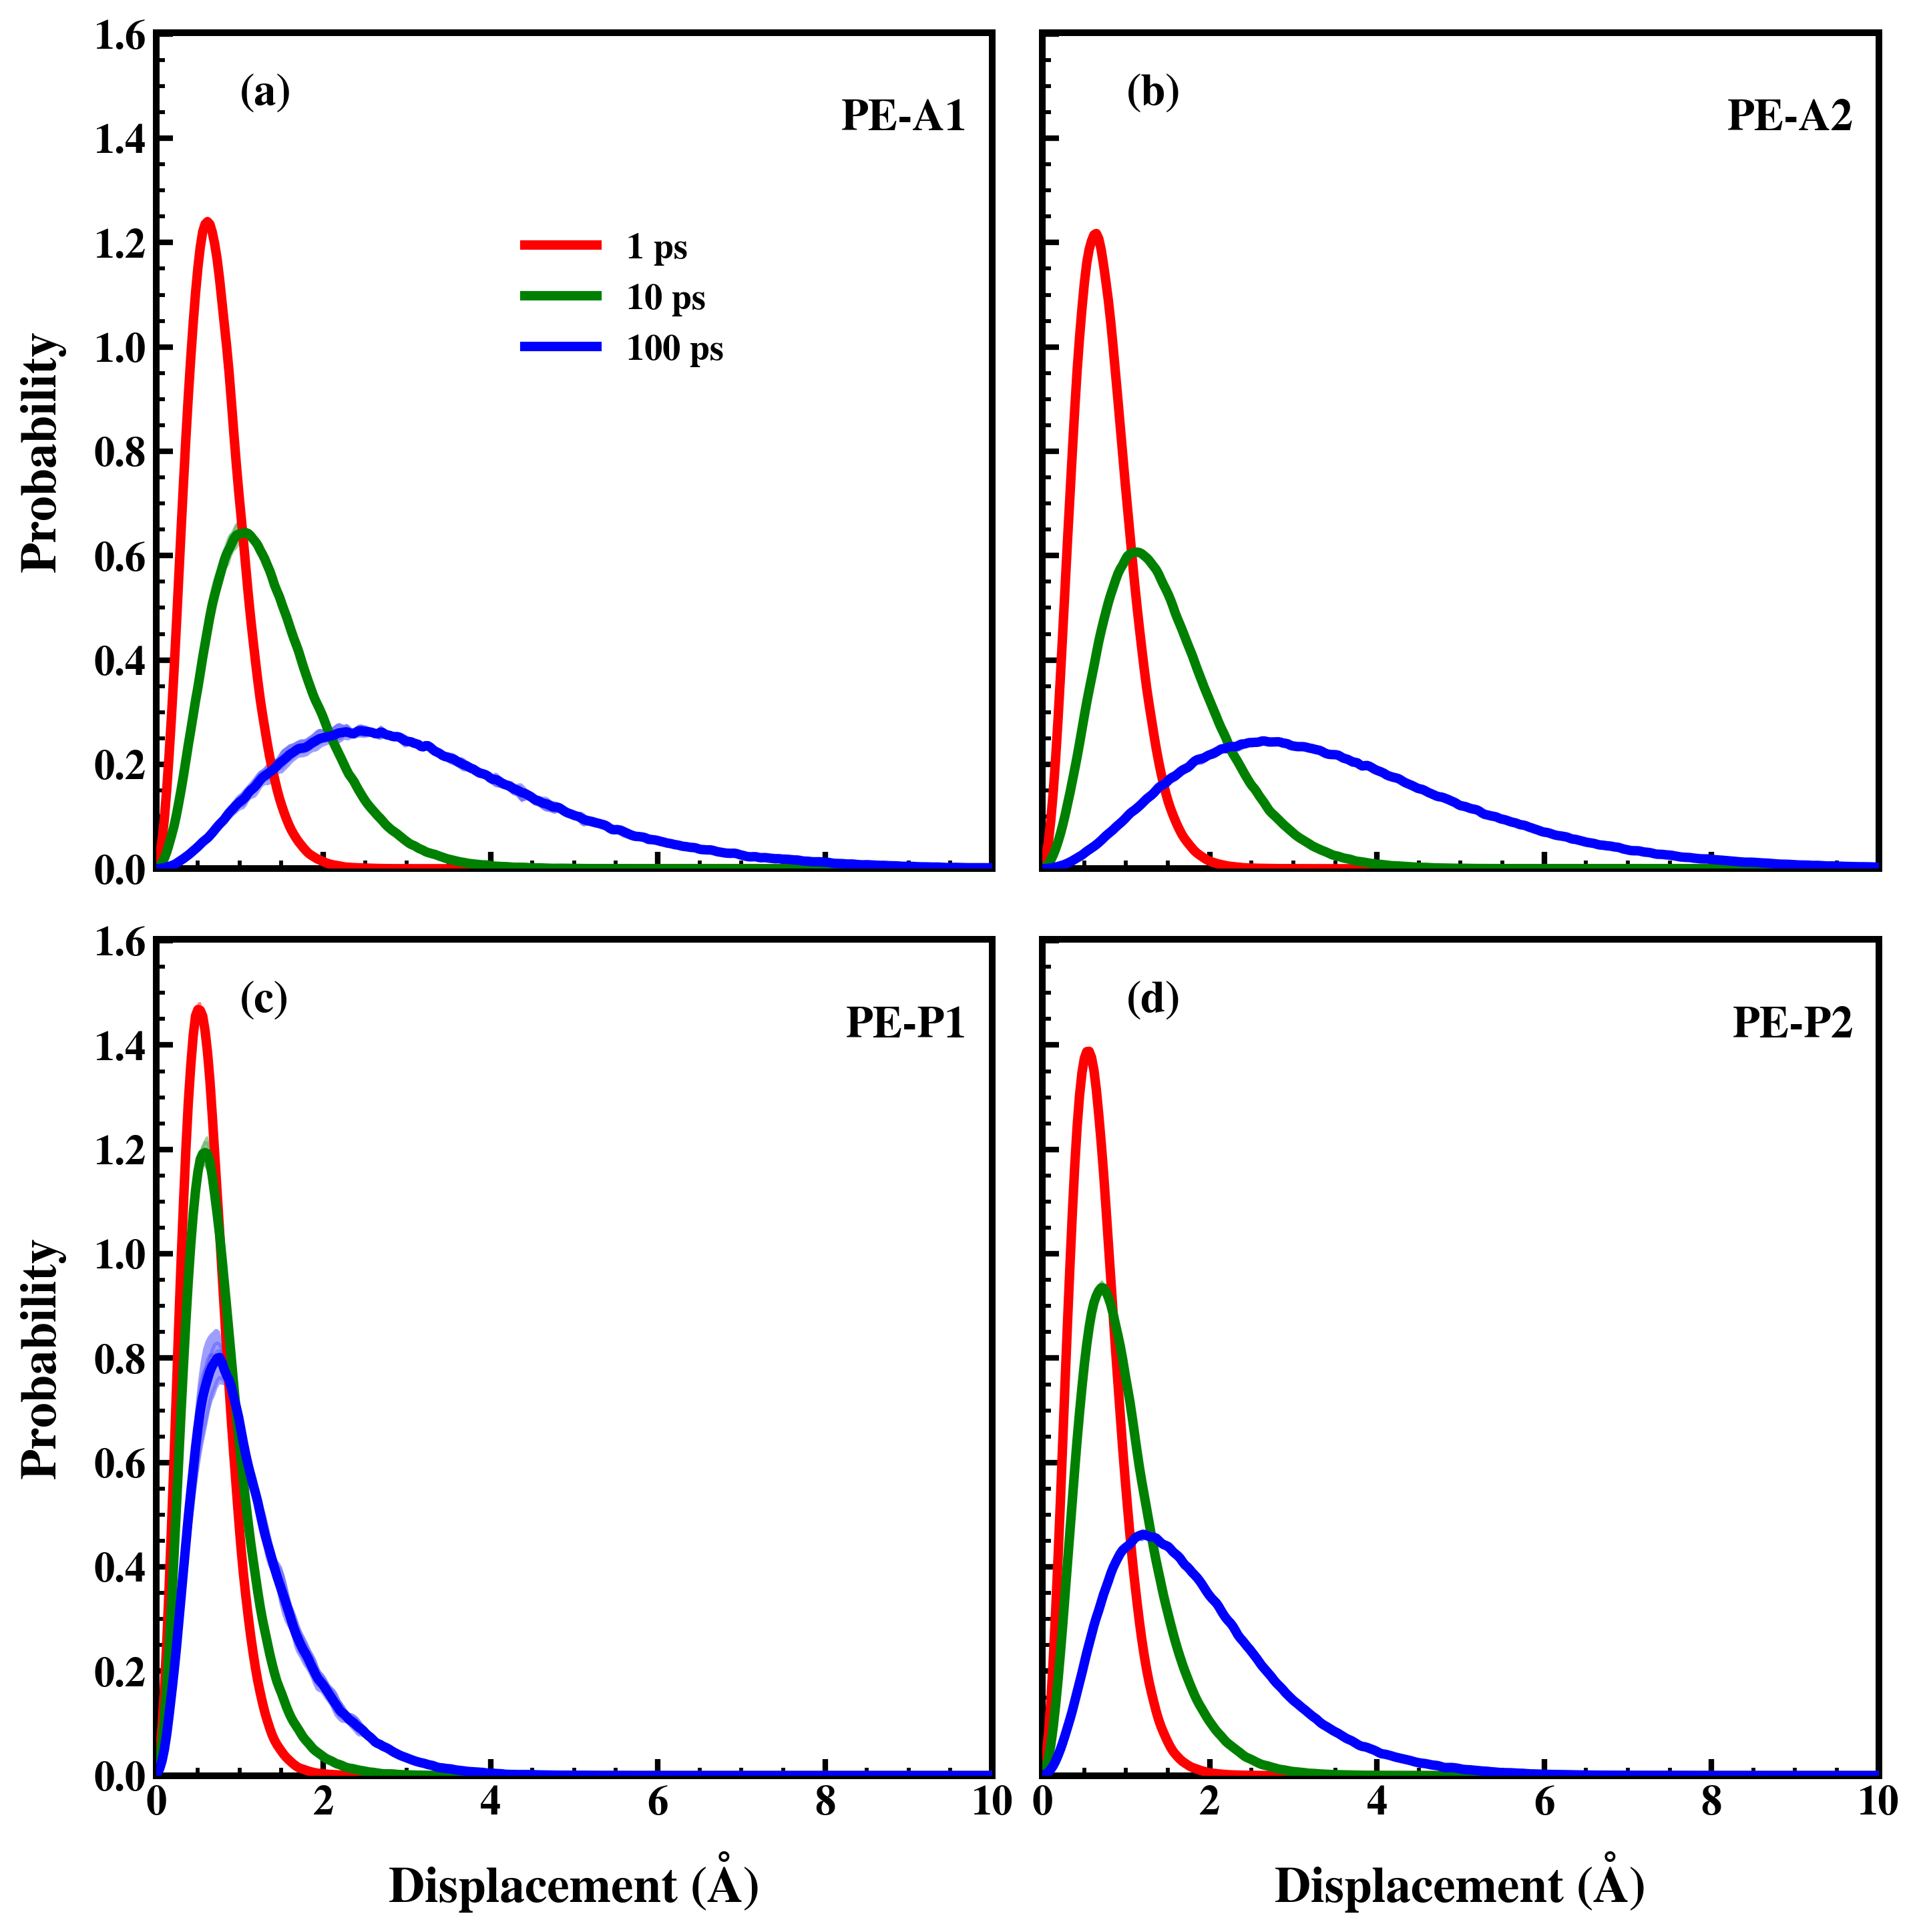


Saved:
van_hove_2x2_replicas_shadowbands.png
van_hove_2x2_replicas_shadowbands.pdf


In [2]:
#!/usr/bin/env python3

import os
import fileinput
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
from scipy.ndimage import gaussian_filter1d

# =========================================================
# SETTINGS
# =========================================================
BASE = "/blue/jsampath/avemula/Paper1_PE/Classical"

SYSTEMS = {
    "PE-A1": {
        "atom_type": 10,
        "files": [
            f"{BASE}/PE_A1/Replica1/linear.lammpstrj",
            f"{BASE}/PE_A1/Replica2/linear.lammpstrj",
            f"{BASE}/PE_A1/Replica3/linear.lammpstrj",
        ],
    },
    "PE-A2": {
        "atom_type": 9,
        "files": [
            f"{BASE}/PE_A2/Replica1/linear.lammpstrj",
            f"{BASE}/PE_A2/Replica2/linear.lammpstrj",
            f"{BASE}/PE_A2/Replica3/linear.lammpstrj",
        ],
    },
    "PE-P1": {
        "atom_type": 10,
        "files": [
            f"{BASE}/PE_P1/Replica1/linear.lammpstrj",
            f"{BASE}/PE_P1/Replica2/linear.lammpstrj",
            f"{BASE}/PE_P1/Replica3/linear.lammpstrj",
        ],
    },
    "PE-P2": {
        "atom_type": 9,
        "files": [
            f"{BASE}/PE_P2/Replica1/linear.lammpstrj",
            f"{BASE}/PE_P2/Replica2/linear.lammpstrj",
            f"{BASE}/PE_P2/Replica3/linear.lammpstrj",
        ],
    },
}

TIME_CUTOFF = 1000000
TIME_DIVIDE = 1000.0
LAGS_PS = [1.0, 10.0, 100.0]

FILTERED_SUFFIX = "Only_target_type.lammpstrj"

OUT_PNG = "van_hove_2x2_replicas_shadowbands.png"
OUT_PDF = "van_hove_2x2_replicas_shadowbands.pdf"

# =========================================================
# PLOT SETTINGS
# =========================================================
XMIN = 0.0
XMAX = 10.0
NBINS = 350
BINS = np.linspace(XMIN, XMAX, NBINS)
SMOOTH_SIGMA = 1.0
DPI = 300

LINEWIDTH_MEAN = 3.4
LINEWIDTH_REPLICA = 1.2
REPLICA_ALPHA = 0.22
BAND_ALPHA = 0.38

AXIS_WIDTH = 2.4
MAJOR_TICK_WIDTH = 2.0
MINOR_TICK_WIDTH = 1.4
MAJOR_TICK_LEN = 6
MINOR_TICK_LEN = 3

LABEL_SIZE = 18
TICK_SIZE = 15
TEXT_SIZE = 16
LEGEND_SIZE = 13

# increase band only for visibility
BAND_SCALE = 1.5

colors = {
    1.0: "red",
    10.0: "green",
    100.0: "blue",
}

labels = {
    1.0: "1 ps",
    10.0: "10 ps",
    100.0: "100 ps",
}

# ACS-like style
mpl.rcParams["font.family"] = "sans-serif"
mpl.rcParams["font.sans-serif] = ""Arial", "Helvetica", "DejaVu Sans""
mpl.rcParams["mathtext.fontset"] = "stix"
mpl.rcParams["axes.linewidth"] = AXIS_WIDTH
mpl.rcParams["xtick.major.width"] = MAJOR_TICK_WIDTH
mpl.rcParams["ytick.major.width"] = MAJOR_TICK_WIDTH
mpl.rcParams["xtick.minor.width"] = MINOR_TICK_WIDTH
mpl.rcParams["ytick.minor.width"] = MINOR_TICK_WIDTH
mpl.rcParams["xtick.major.size"] = MAJOR_TICK_LEN
mpl.rcParams["ytick.major.size"] = MAJOR_TICK_LEN
mpl.rcParams["xtick.minor.size"] = MINOR_TICK_LEN
mpl.rcParams["ytick.minor.size"] = MINOR_TICK_LEN



# =========================================================
# FILTER ONE TRAJECTORY
# =========================================================
def filter_trajectory(input_traj, atom_type_to_keep):
    outdir = os.path.dirname(input_traj)
    filtered_traj = os.path.join(outdir, FILTERED_SUFFIX)

    print(f"\nFiltering file:\n  {input_traj}")
    print(f"Output filtered file:\n  {filtered_traj}")

    with open(filtered_traj, "w") as OUT:
        IN = fileinput.input([input_traj])

        while True:
            headers = [IN.readline() for _ in range(9)]
            if any(h == "" for h in headers):
                break

            try:
                natoms = int(headers[3].strip())
            except ValueError:
                raise RuntimeError(f"Could not parse NUMBER OF ATOMS in file: {input_traj}")

            kept_atoms = []
            for _ in range(natoms):
                line = IN.readline()
                if line == "":
                    raise RuntimeError(f"Unexpected EOF inside atom block in file: {input_traj}")

                parts = line.split()
                if len(parts) < 3:
                    raise RuntimeError(f"Malformed atom line in {input_traj}:\n{line}")

                typ = int(parts[2])
                if typ == atom_type_to_keep:
                    kept_atoms.append(line)

            OUT.writelines(headers[:3])
            OUT.write(f"{len(kept_atoms)}\n")
            OUT.writelines(headers[4:])
            for atom_line in kept_atoms:
                OUT.write(atom_line)

    print(f"Done filtering: {filtered_traj}")
    return filtered_traj


# =========================================================
# READ FILTERED FILE
# =========================================================
def read_filtered_traj(filtered_traj, time_cutoff, time_divide):
    """
    Reads filtered trajectory with columns:
    ITEM: ATOMS id mol type x y z xu yu zu
    """
    col_names = ["id", "mol", "type", "x", "y", "z", "xu", "yu", "zu"]

    with open(filtered_traj, "r") as f:
        lines = f.readlines()

    if len(lines) < 9:
        raise RuntimeError(f"Filtered trajectory is too short or empty: {filtered_traj}")

    data = []
    num_particles = None

    for i in range(len(lines)):
        if "ITEM: TIMESTEP" in lines[i]:
            timestep = int(lines[i + 1])

            if timestep > time_cutoff:
                break

            num_particles = int(lines[i + 3].strip())

            for j in range(i + 9, i + 9 + num_particles):
                parts = lines[j].split()
                if len(parts) < 9:
                    continue

                particle_id, mol, particle_type, x, y, z, xu, yu, zu = parts[:9]
                data.append([
                    timestep,
                    particle_id,
                    mol,
                    particle_type,
                    x, y, z, xu, yu, zu
                ])

    df = pd.DataFrame(data, columns=["time"] + col_names)

    if df.empty:
        raise RuntimeError(f"No data found in filtered file: {filtered_traj}")

    df[["id", "mol", "type"]] = df[["id", "mol", "type"]].astype(int)
    df[["x", "y", "z", "xu", "yu", "zu"]] = df[["x", "y", "z", "xu", "yu", "zu"]].astype(float)
    df["time"] = df["time"].astype(int) / time_divide

    # use xu yu zu directly
    df["xa"] = df["xu"]
    df["ya"] = df["yu"]
    df["za"] = df["zu"]

    df = df.sort_values(["time", "id"]).reset_index(drop=True)
    times = np.sort(df["time"].unique())

    if len(times) < 2:
        raise RuntimeError(f"Not enough frames in {filtered_traj}")

    dt_ps = times[1] - times[0]

    print(f"Read filtered file: {filtered_traj}")
    print("DataFrame shape:", df.shape)
    print("num_particles =", num_particles)
    print("first few times =", times[:10], "...")
    print("Frame spacing (ps) =", dt_ps)

    return df, times, dt_ps, num_particles


# =========================================================
# COLLECT DRIFT-CORRECTED DISPLACEMENTS
# =========================================================
def collect_displacements_for_lag(df, times, lag_ps, time_tol=1e-8):
    out = []
    time_set = set(np.round(times, 8))

    for t0 in times:
        t1 = t0 + lag_ps

        if np.round(t1, 8) not in time_set:
            continue

        f0 = df[np.isclose(df["time"], t0, atol=time_tol)].sort_values("id").reset_index(drop=True)
        f1 = df[np.isclose(df["time"], t1, atol=time_tol)].sort_values("id").reset_index(drop=True)

        ids0 = f0["id"].to_numpy()
        ids1 = f1["id"].to_numpy()

        common_ids, idx0, idx1 = np.intersect1d(
            ids0, ids1,
            assume_unique=False,
            return_indices=True
        )

        if len(common_ids) == 0:
            continue

        r0 = f0.loc[idx0, ["xa", "ya", "za"]].to_numpy()
        r1 = f1.loc[idx1, ["xa", "ya", "za"]].to_numpy()

        dr_vec = r1 - r0

        # drift correction
        drift = dr_vec.mean(axis=0)
        dr_vec = dr_vec - drift

        dr = np.linalg.norm(dr_vec, axis=1)
        dr = dr[np.isfinite(dr)]

        if dr.size > 0:
            out.append(dr)

    if len(out) == 0:
        raise RuntimeError(f"No displacements found for lag {lag_ps} ps")

    return np.concatenate(out)


# =========================================================
# CONVERT ONE REPLICA DISPLACEMENT ARRAY TO SMOOTH HISTOGRAM
# =========================================================
def displacement_to_hist(dr, bins):
    dr_plot = dr[(dr >= bins[0]) & (dr <= bins[-1])]

    if dr_plot.size == 0:
        return None, None

    hist, _ = np.histogram(dr_plot, bins=bins, density=True)
    hist_smooth = gaussian_filter1d(hist, sigma=SMOOTH_SIGMA)
    centers = 0.5 * (bins[:-1] + bins[1:])

    return centers, hist_smooth


# =========================================================
# PROCESS ONE SYSTEM
# =========================================================
def process_system(system_name, system_info):
    atom_type_to_keep = system_info["atom_type"]
    traj_files = system_info["files"]

    replica_results = []

    print("\n" + "=" * 80)
    print(f"Processing system: {system_name}")
    print("=" * 80)

    for traj_file in traj_files:
        if not os.path.exists(traj_file):
            print(f"WARNING: file not found, skipping:\n  {traj_file}")
            continue

        try:
            filtered_traj = filter_trajectory(traj_file, atom_type_to_keep)

            df, times, dt_ps, num_particles = read_filtered_traj(
                filtered_traj,
                time_cutoff=TIME_CUTOFF,
                time_divide=TIME_DIVIDE
            )

            replica_dict = {}

            for lag_ps in LAGS_PS:
                ratio = lag_ps / dt_ps
                if not np.isclose(ratio, round(ratio), atol=1e-8):
                    raise RuntimeError(
                        f"Requested lag {lag_ps} ps is not an integer multiple of "
                        f"frame spacing {dt_ps} ps for file {traj_file}"
                    )

                dr = collect_displacements_for_lag(df, times, lag_ps)
                replica_dict[lag_ps] = dr

                print(f"\nReplica file: {traj_file}")
                print(f"lag_ps     = {lag_ps}")
                print(f"count      = {len(dr)}")
                print(f"min/max    = {dr.min():.4f}, {dr.max():.4f}")
                print(f"mean       = {dr.mean():.4f}")
                print(f"std        = {dr.std():.4f}")

            replica_results.append(replica_dict)

        except Exception as e:
            print(f"WARNING: skipping replica due to error:\n  {traj_file}\n  {e}")
            continue

    if len(replica_results) == 0:
        raise RuntimeError(f"No valid replicas found for system {system_name}")

    return replica_results


# =========================================================
# HISTOGRAM MEAN/STD FOR ONE SYSTEM AND ONE LAG
# =========================================================
def histogram_mean_std(replica_results_for_one_system, lag_ps, bins):
    hists = []
    centers_out = None

    for replica_dict in replica_results_for_one_system:
        if lag_ps not in replica_dict:
            continue

        dr = replica_dict[lag_ps]
        centers, hist_smooth = displacement_to_hist(dr, bins)

        if centers is None:
            continue

        centers_out = centers
        hists.append(hist_smooth)

    if len(hists) == 0:
        raise RuntimeError(f"No histogram data found for lag {lag_ps}")

    hists = np.array(hists)
    mean_hist = np.mean(hists, axis=0)

    if hists.shape[0] > 1:
        std_hist = np.std(hists, axis=0, ddof=1)
    else:
        std_hist = np.zeros_like(mean_hist)

    return centers_out, mean_hist, std_hist, hists


# =========================================================
# RUN ALL SYSTEMS
# =========================================================
all_results = {}

for sys_name, sys_info in SYSTEMS.items():
    all_results[sys_name] = process_system(sys_name, sys_info)


# =========================================================
# GLOBAL Y-LIMIT
# =========================================================
all_ymax_candidates = []

for sys_name in ["PE-A1", "PE-A2", "PE-P1", "PE-P2"]:
    replica_results = all_results[sys_name]

    for lag in LAGS_PS:
        centers, mean_hist, std_hist, hists = histogram_mean_std(
            replica_results_for_one_system=replica_results,
            lag_ps=lag,
            bins=BINS
        )

        upper = mean_hist + BAND_SCALE * std_hist
        all_ymax_candidates.append(np.max(upper))

YMIN = 0.0
YMAX = 1.08 * max(all_ymax_candidates)


# =========================================================
# CREATE 2x2 PANEL LAYOUT
# =========================================================
fig, axes = plt.subplots(
    2, 2,
    figsize=(10, 10),
    dpi=DPI,
    sharex=True,
    sharey=True
)

axes = axes.flatten()
system_order = ["PE-A1", "PE-A2", "PE-P1", "PE-P2"]
panel_tags = ["(a)", "(b)", "(c)", "(d)"]

for i, (ax, sys_name) in enumerate(zip(axes, system_order)):
    replica_results = all_results[sys_name]

    for lag in LAGS_PS:
        centers, mean_hist, std_hist, hists = histogram_mean_std(
            replica_results_for_one_system=replica_results,
            lag_ps=lag,
            bins=BINS
        )

        # faint individual replica curves to show replica usage
        for hist_rep in hists:
            ax.plot(
                centers,
                hist_rep,
                lw=LINEWIDTH_REPLICA,
                color=colors[lag],
                alpha=REPLICA_ALPHA,
                zorder=1
            )

        # visible shadow band
        lower = np.clip(mean_hist - BAND_SCALE * std_hist, 0, None)
        upper = mean_hist + BAND_SCALE * std_hist

        ax.fill_between(
            centers,
            lower,
            upper,
            color=colors[lag],
            alpha=BAND_ALPHA,
            linewidth=0,
            zorder=2
        )

        # thick mean curve
        ax.plot(
            centers,
            mean_hist,
            lw=LINEWIDTH_MEAN,
            color=colors[lag],
            label=labels[lag],
            zorder=3
        )

    ax.set_xlim(XMIN, XMAX)
    ax.set_ylim(YMIN, YMAX)

    ax.text(
        0.10, 0.95, panel_tags[i],
        transform=ax.transAxes,
        ha="left",
        va="top",
        fontsize=TEXT_SIZE,
        fontweight="bold"
    )

    ax.text(
        0.97, 0.92, sys_name,
        transform=ax.transAxes,
        ha="right",
        va="top",
        fontsize=TEXT_SIZE,
        fontweight="bold"
    )

    ax.tick_params(
        axis="both",
        which="major",
        direction="in",
        labelsize=TICK_SIZE,
        width=MAJOR_TICK_WIDTH,
        length=MAJOR_TICK_LEN,
        top=False,
        right=False
    )

    ax.tick_params(
        axis="both",
        which="minor",
        direction="in",
        width=MINOR_TICK_WIDTH,
        length=MINOR_TICK_LEN,
        top=False,
        right=False
    )

    ax.minorticks_on()

    for tick in ax.get_xticklabels():
        tick.set_fontweight("bold")
    for tick in ax.get_yticklabels():
        tick.set_fontweight("bold")

    for spine in ax.spines.values():
        spine.set_linewidth(AXIS_WIDTH)

    ax.set_box_aspect(1)

# Left column y-labels only
axes[0].set_ylabel("Probability", fontsize=LABEL_SIZE, fontweight="bold", labelpad=10)
axes[2].set_ylabel("Probability", fontsize=LABEL_SIZE, fontweight="bold", labelpad=10)

# Bottom row x-labels only
axes[2].set_xlabel("Displacement (Å)", fontsize=LABEL_SIZE, fontweight="bold", labelpad=10)
axes[3].set_xlabel("Displacement (Å)", fontsize=LABEL_SIZE, fontweight="bold", labelpad=10)

# Hide top-row x tick labels
axes[0].tick_params(labelbottom=False)
axes[1].tick_params(labelbottom=False)

# Hide right-column y tick labels
axes[1].tick_params(labelleft=False)
axes[3].tick_params(labelleft=False)

# Legend only in first panel
axes[0].legend(
    loc="upper center",
    bbox_to_anchor=(0.56, 0.80),
    ncol=1,
    frameon=False,
    prop={"weight": "bold", "size": LEGEND_SIZE}
)

# Spacing
plt.subplots_adjust(
    hspace=0.06,
    wspace=0.06,
    left=0.12,
    right=0.98,
    bottom=0.10,
    top=0.98
)

plt.savefig(OUT_PNG, dpi=DPI, bbox_inches="tight")
plt.savefig(OUT_PDF, dpi=DPI, bbox_inches="tight")
plt.show()

print("\nSaved:")
print(OUT_PNG)
print(OUT_PDF)